In [3]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Visualization helper function
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")
    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")
    fig.show()

Note: you may need to restart the kernel to use updated packages.


2026-04-22 09:24:42.179494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 09:24:42.660028: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 09:24:44.946529: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
"""
SELECT
    time_bucket_gapfill('30 seconds'::interval, bucket)::TIMESTAMP AS timestamp,
    signal,
    locf(last(last_value, bucket)) AS last_value
FROM
    normalized_signal_30sec
WHERE
    bucket between '2026-04-01 21:28:00.000000'::timestamp AND '2026-04-01 22:52:00.000000'::timestamp
  AND deviceid = 'b6371919-dc67-4b5a-89bb-9e8d02e1bfd5'
GROUP BY
    timestamp,
    signal
ORDER BY
    timestamp asc, signal;
"""

data_df = pd.read_csv('SG000005.csv')
data_df.tail()

dups_num = data_df.duplicated(subset=['timestamp', 'signal']).sum()

if dups_num > 0:
    data_df.drop_duplicates(subset=['timestamp', 'signal'], inplace=True)
    data_df.reset_index(drop=True, inplace=True)
    data_df.duplicated().sum()

data_df.tail()

,timestamp,signal,last_value
707767,2026-04-01 22:52:00.000000,wakeReason_BMS01,1.0
707768,2026-04-01 22:52:00.000000,wakeReason_BMS05,1.0
707769,2026-04-01 22:52:00.000000,wakeReason_BMS09,1.0
707770,2026-04-01 22:52:00.000000,wakeReason_BMS13,1.0
707771,2026-04-01 22:52:00.000000,wakeReason_BMS21,1.0


In [5]:
context_df = data_df.pivot(index='timestamp', columns='signal', values='last_value')
context_df.head()
len(context_df)

context_df.columns.name = None # to remove column groups
context_df.reset_index(inplace=True)
context_df.tail()

,timestamp,ADCU_MCU_Major,ADCU_MCU_Minor,ADCU_MCU_Subminor,ADCU_SOC_Major,ADCU_SOC_Minor,ADCU_SOC_Subminor,BCM_Air_Temp_ThermalBox,BCM_BPV_Position_Current,BCM_BattActiveCoolReq,...,variantCodingCount_BMS01,variantCodingCount_BMS05,variantCodingCount_BMS09,variantCodingCount_BMS13,variantCodingCount_BMS21,wakeReason_BMS01,wakeReason_BMS05,wakeReason_BMS09,wakeReason_BMS13,wakeReason_BMS21
164,2026-04-01 22:50:00.000000,4.0,23.0,1.0,4.0,23.0,1.0,29.0,220.0,0.0,...,64.0,64.0,63.0,63.0,63.0,1.0,1.0,1.0,1.0,1.0
165,2026-04-01 22:50:30.000000,4.0,23.0,1.0,4.0,23.0,1.0,29.0,220.0,0.0,...,64.0,64.0,63.0,63.0,63.0,1.0,1.0,1.0,1.0,1.0
166,2026-04-01 22:51:00.000000,4.0,23.0,1.0,4.0,23.0,1.0,29.0,220.0,0.0,...,64.0,64.0,63.0,63.0,63.0,1.0,1.0,1.0,1.0,1.0
167,2026-04-01 22:51:30.000000,4.0,23.0,1.0,4.0,23.0,1.0,29.0,220.0,0.0,...,64.0,64.0,63.0,63.0,63.0,1.0,1.0,1.0,1.0,1.0
168,2026-04-01 22:52:00.000000,4.0,23.0,1.0,4.0,23.0,1.0,29.0,30.0,0.0,...,64.0,64.0,63.0,63.0,63.0,1.0,1.0,1.0,1.0,1.0


In [6]:
# keep only columns where values non NaN are >90%
context_df.dropna(axis=1, thresh=len(context_df) * 0.1, inplace=True)
context_df.tail()

context_df['timestamp'] = pd.to_datetime(context_df['timestamp'])
context_df.reset_index(inplace=True)
context_df.drop(columns='index', inplace=True)
context_df.head()

# check if any time gaps
expected_range = pd.date_range(start=context_df['timestamp'].min(), end=context_df['timestamp'].max(), freq='30s')
missing_dates = expected_range.difference(context_df['timestamp'])
missing_dates

context_df.describe()

context_df = context_df.loc[:, context_df.nunique() > 1] # drop all columns where value is not changing
context_df.describe()

,timestamp,BCM_Air_Temp_ThermalBox,BCM_BPV_Position_Current,BCM_BrakePedalSwitch_State,BCM_CabinCoolReq,BCM_CoolantLoop_State,BCM_Degradation_State,BCM_DriveAllow,BCM_DriveInhibit_Keyfob,BCM_EOP_CURR,...,stringState_BMS01,stringState_BMS05,stringState_BMS09,stringState_BMS13,stringState_BMS21,stringVoltage_BMS01,stringVoltage_BMS05,stringVoltage_BMS09,stringVoltage_BMS13,stringVoltage_BMS21
count,169,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,...,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,2026-04-01 22:09:59.999999744,29.355030,218.875740,0.449704,0.952663,2.905325,0.994083,0.994083,0.005917,3.856805,...,0.994083,0.994083,0.994083,0.994083,0.994083,777.369231,777.345089,777.352426,777.340592,777.375858
min,2026-04-01 21:28:00,28.000000,30.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,738.880000,738.880000,738.680000,738.560000,739.400000
25%,2026-04-01 21:49:00,29.000000,220.000000,0.000000,1.000000,3.000000,1.000000,1.000000,0.000000,2.200000,...,1.000000,1.000000,1.000000,1.000000,1.000000,772.000000,771.920000,771.920000,771.920000,772.040000
50%,2026-04-01 22:10:00,29.000000,220.000000,0.000000,1.000000,3.000000,1.000000,1.000000,0.000000,2.600000,...,1.000000,1.000000,1.000000,1.000000,1.000000,779.880000,779.720000,779.880000,779.840000,779.880000
75%,2026-04-01 22:31:00,30.000000,220.000000,1.000000,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,...,1.000000,1.000000,1.000000,1.000000,1.000000,783.520000,783.600000,783.560000,783.560000,783.560000
max,2026-04-01 22:52:00,31.000000,220.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,9.600000,...,1.000000,1.000000,1.000000,1.000000,1.000000,790.040000,790.040000,790.040000,790.080000,789.960000
std,NaN,0.591096,14.615385,0.586670,0.212990,0.425981,0.076923,0.076923,0.076923,2.342077,...,0.076923,0.076923,0.076923,0.076923,0.076923,9.050788,9.120852,9.117713,9.120630,8.988921


In [7]:
context_df['id'] = 'b6371919-dc67-4b5a-89bb-9e8d02e1bfd5'
context_df.head()

from sklearn.model_selection import train_test_split
input_df, test_df = train_test_split(context_df, test_size=0.3, shuffle=False)
input_df.head()
len(test_df)

51

In [17]:
import matplotlib.pyplot as plt

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

pred_df = pipeline.predict_df(
    input_df,
    future_df=None,
    prediction_length=len(test_df),
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id',
    timestamp_column='timestamp',
    target='VCU_CWTI_IBGT_Temp',
)

pred_df.head()

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,b6371919-dc67-4b5a-89bb-9e8d02e1bfd5,2026-04-01 22:27:00,VCU_CWTI_IBGT_Temp,38.440273,28.703461,38.440273,55.175129
1,b6371919-dc67-4b5a-89bb-9e8d02e1bfd5,2026-04-01 22:27:30,VCU_CWTI_IBGT_Temp,37.989368,28.505230,37.989368,55.527397
2,b6371919-dc67-4b5a-89bb-9e8d02e1bfd5,2026-04-01 22:28:00,VCU_CWTI_IBGT_Temp,37.204460,27.887964,37.204460,53.723396
3,b6371919-dc67-4b5a-89bb-9e8d02e1bfd5,2026-04-01 22:28:30,VCU_CWTI_IBGT_Temp,37.937511,27.098068,37.937511,55.833569
4,b6371919-dc67-4b5a-89bb-9e8d02e1bfd5,2026-04-01 22:29:00,VCU_CWTI_IBGT_Temp,39.170731,27.813786,39.170731,57.992992


/tmp/ipykernel_136256/293340939.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


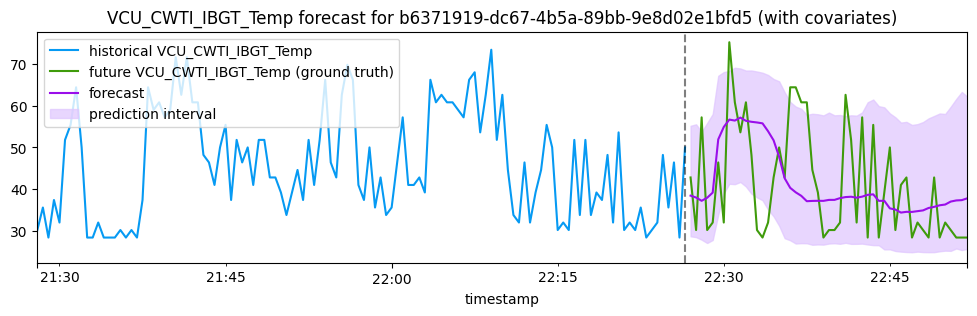

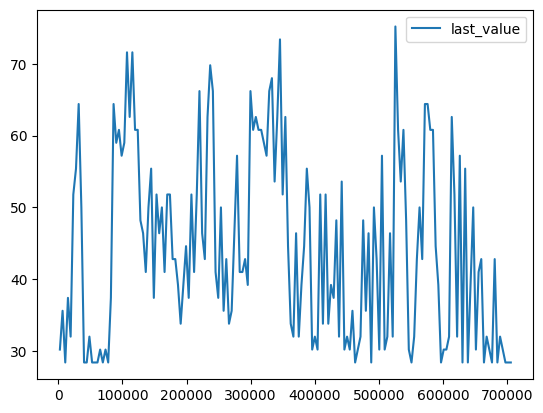

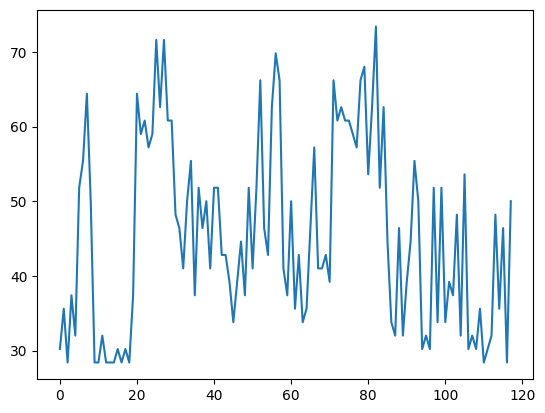

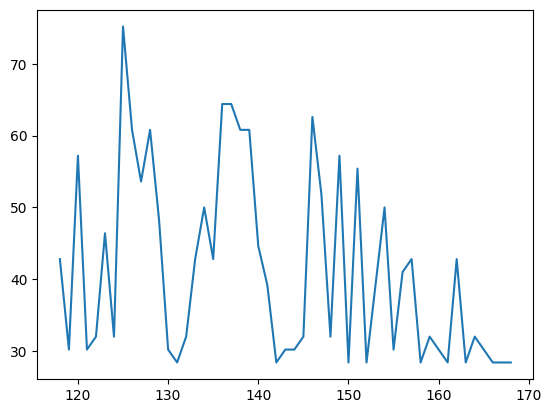

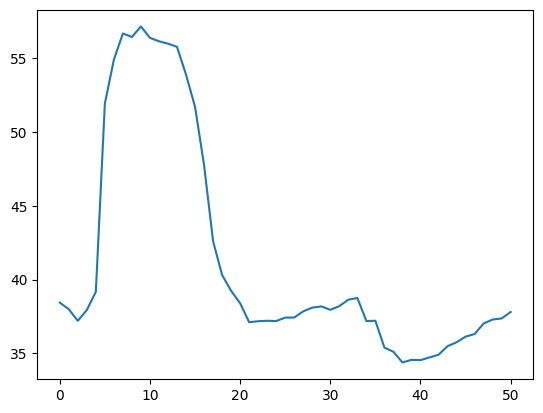

In [19]:
plot_forecast(
    input_df,
    pred_df,
    test_df,
    target_column='VCU_CWTI_IBGT_Temp',
    timeseries_id='b6371919-dc67-4b5a-89bb-9e8d02e1bfd5',
    title_suffix="(with covariates)",
)

data_df[data_df['signal'] == 'VCU_CWTI_IBGT_Temp'].plot()
plt.show()

input_df['VCU_CWTI_IBGT_Temp'].plot()
plt.show()

test_df['VCU_CWTI_IBGT_Temp'].plot()
plt.show()

pred_df['predictions'].plot()
plt.show()